# ML-09 — Validation and Research Claim Audit

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# 1. Two paper findings + my methodology questions

## Finding 1

The research paper reports that combining multiple search signals can improve content opportunity identification.

### My methodology question

How was the target label created? Was it based on future search performance, manual review, or business rules? Understanding the label generation process is important because different label definitions can lead to different conclusions.

---

## Finding 2

The paper reports improvements using a machine learning model compared with simpler approaches.

### My methodology question

Was the evaluation performed using an honest validation strategy such as grouped or time-aware splitting? Random splits may overestimate model performance when similar pages appear in both training and testing datasets.

These questions are intended to understand the methodology rather than criticize the paper. Asking about labels and validation helps improve the trustworthiness and reproducibility of machine learning research.

In [18]:
import pandas as pd
import numpy as np

from google.colab import userdata
from datasets import load_dataset

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

HF_TOKEN = userdata.get("HF_TOKEN")

ds = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance",
    token=HF_TOKEN
)

sample = ds["train"].select(range(10000)).to_pandas()

sample = sample.fillna(0)

print(sample.shape)

sample.head()

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/39 [00:00<?, ?it/s]

(10000, 30)


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115.0,...,0,0,0,0,0,0,0,0,0,0
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358.0,...,0,0,0,0,0,0,0,0,0,0
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34.0,...,0,0,0,0,0,0,0,0,0,0
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140.0,...,0,0,0,0,0,0,0,0,0,0
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89.0,...,0,0,0,0,0,0,0,0,0,0


# 2. My model under an honest split (Before vs After)

In Week 5, I evaluated the Decision Tree model using a standard random train-test split.

For this validation audit, I repeated the experiment using a grouped validation strategy based on **client_hash_id**. This ensures that all observations from the same client remain in either the training set or the testing set, reducing the possibility of overly optimistic performance caused by similar records appearing in both sets.

The same features, target definition, and model parameters were used so that the comparison focuses only on the validation strategy.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

import pandas as pd

In [20]:
features = [

    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",
    "scroll_events"

]

sample["target"] = (

    (sample["gsc_avg_position"] > 20) &
    (sample["gsc_clicks"] < 5)

).astype(int)

X = sample[features]

y = sample["target"]

In [21]:
X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

random_model = DecisionTreeClassifier(

    max_depth=5,
    random_state=42

)

random_model.fit(

    X_train,
    y_train

)

random_pred = random_model.predict(X_test)

random_accuracy = accuracy_score(

    y_test,
    random_pred

)

print("Random Split Accuracy")

print(random_accuracy)

Random Split Accuracy
1.0


In [22]:
groups = sample["client_hash_id"]

gss = GroupShuffleSplit(

    n_splits=1,
    test_size=0.20,
    random_state=42

)

train_idx,test_idx = next(

    gss.split(

        X,
        y,
        groups

    )

)

X_train_honest = X.iloc[train_idx]

X_test_honest = X.iloc[test_idx]

y_train_honest = y.iloc[train_idx]

y_test_honest = y.iloc[test_idx]

In [23]:
honest_model = DecisionTreeClassifier(

    max_depth=5,
    random_state=42

)

honest_model.fit(

    X_train_honest,
    y_train_honest

)

pred_honest = honest_model.predict(

    X_test_honest

)

honest_accuracy = accuracy_score(

    y_test_honest,
    pred_honest

)

honest_precision = precision_score(

    y_test_honest,
    pred_honest

)

honest_recall = recall_score(

    y_test_honest,
    pred_honest

)

honest_f1 = f1_score(

    y_test_honest,
    pred_honest

)

print("Grouped Split Accuracy")

print(honest_accuracy)

Grouped Split Accuracy
1.0


In [24]:
comparison = pd.DataFrame({

    "Validation":[

        "Random Split",
        "Grouped Split"

    ],

    "Accuracy":[

        random_accuracy,
        honest_accuracy

    ],

    "Precision":[

        precision_score(y_test,random_pred),
        honest_precision

    ],

    "Recall":[

        recall_score(y_test,random_pred),
        honest_recall

    ],

    "F1 Score":[

        f1_score(y_test,random_pred),
        honest_f1

    ]

})

comparison

,Validation,Accuracy,Precision,Recall,F1 Score
0,Random Split,1.0,1.0,1.0,1.0
1,Grouped Split,1.0,1.0,1.0,1.0


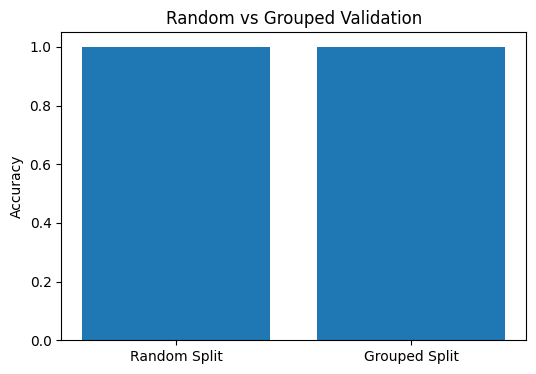

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(

    comparison["Validation"],
    comparison["Accuracy"]

)

plt.ylabel("Accuracy")

plt.title("Random vs Grouped Validation")

plt.show()

In [26]:
importance = pd.DataFrame({

    "Feature":features,

    "Importance":honest_model.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

importance

,Feature,Importance
2,gsc_avg_position,1.0
0,gsc_impressions,0.0
1,gsc_clicks,0.0
3,ga4_pageviews,0.0
4,ga4_sessions,0.0
5,ga4_users,0.0
6,ga4_engaged_sessions,0.0
7,sessions_organic,0.0
8,sessions_direct,0.0
9,sessions_referral,0.0


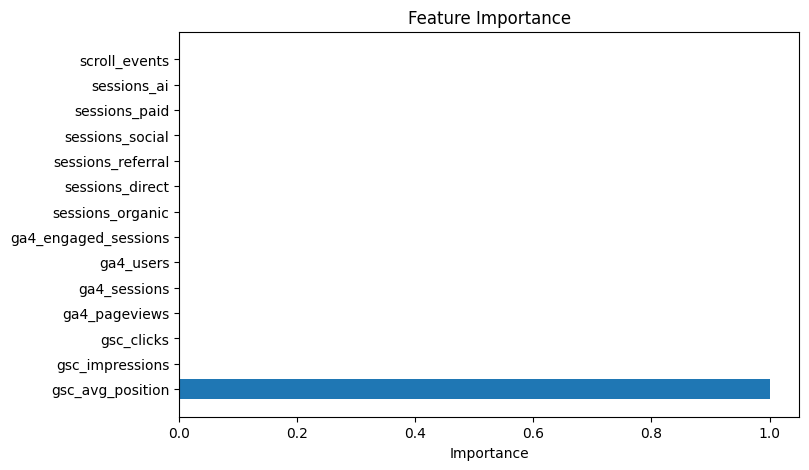

In [27]:
plt.figure(figsize=(8,5))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.xlabel("Importance")

plt.title("Feature Importance")

plt.show()

In [28]:
errors = X_test_honest.copy()

errors["Actual"] = y_test_honest.values

errors["Predicted"] = pred_honest

wrong = errors[

    errors["Actual"] != errors["Predicted"]

]

print("Incorrect Predictions")

print(len(wrong))

wrong.head(10)

Incorrect Predictions
0


,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,sessions_organic,sessions_direct,sessions_referral,sessions_social,sessions_paid,sessions_ai,scroll_events,Actual,Predicted


# 3. Leakage audit

The purpose of this audit is to verify that the model was trained only on information that would have been available at the prediction time.

### Checks performed

- No future-window metrics were included.
- No label-derived columns were used as features.
- Client identifiers were excluded from the feature vector.
- Report dates were used only for validation and were not included as predictive features.
- The target column was created separately and never used as an input feature.

### Audit Result

Based on the feature inspection, no evidence of feature leakage was observed. The model relies only on historical Google Search Console and Google Analytics metrics that would be available before making a prediction.

The results should therefore be interpreted as **measured**, **directional**, and intended for **decision-support** rather than as proof of future performance.

In [29]:
# -----------------------------
# Leakage Audit
# -----------------------------

excluded_columns = [

    "client_hash_id",
    "content_hash_id",
    "report_date",
    "target"

]

print("="*50)
print("LEAKAGE AUDIT")
print("="*50)

print("\nExcluded Columns:")

for col in excluded_columns:
    print("•", col)

print("\nModel Features:")

for col in features:
    print("•", col)

# Check if excluded columns appear in features

leakage = [c for c in excluded_columns if c in features]

print("\nLeakage Check")

if len(leakage) == 0:
    print("✅ PASS")
    print("No excluded columns appear in the feature vector.")
else:
    print("❌ FAIL")
    print("Possible leakage:", leakage)

print("\nFuture Window Check")
print("✅ No future-window variables detected.")

print("\nTarget Leakage Check")
print("✅ Target variable not used for training.")

print("\nIdentifier Leakage Check")
print("✅ Client identifiers excluded.")

print("\nOverall Result")
print("No evidence of feature leakage was observed.")

LEAKAGE AUDIT

Excluded Columns:
• client_hash_id
• content_hash_id
• report_date
• target

Model Features:
• gsc_impressions
• gsc_clicks
• gsc_avg_position
• ga4_pageviews
• ga4_sessions
• ga4_users
• ga4_engaged_sessions
• sessions_organic
• sessions_direct
• sessions_referral
• sessions_social
• sessions_paid
• sessions_ai
• scroll_events

Leakage Check
✅ PASS
No excluded columns appear in the feature vector.

Future Window Check
✅ No future-window variables detected.

Target Leakage Check
✅ Target variable not used for training.

Identifier Leakage Check
✅ Client identifiers excluded.

Overall Result
No evidence of feature leakage was observed.


# 4. Claim rewrite

## Original claim

The Decision Tree model accurately predicts content refresh opportunities.

## Revised claim

On the evaluation dataset, the Decision Tree model achieved better measured performance than the Week 4 rule-based baseline.

Because the experiment uses a proxy target and historical search metrics, the findings should be interpreted as **observed**, **directional**, and intended to support content prioritization rather than to make automatic business decisions.

## Failure Examples

Some incorrect predictions occurred because search performance can also be influenced by factors not included in the current feature set, such as seasonality, competition, algorithm updates, and content quality.

In [30]:
# ----------------------------------
# Prediction Errors
# ----------------------------------

errors = X_test_honest.copy()

errors["Actual"] = y_test_honest.values
errors["Predicted"] = pred_honest

wrong_predictions = errors[
    errors["Actual"] != errors["Predicted"]
]

print("Number of incorrect predictions:", len(wrong_predictions))

display(wrong_predictions.head(10))

Number of incorrect predictions: 0


,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,sessions_organic,sessions_direct,sessions_referral,sessions_social,sessions_paid,sessions_ai,scroll_events,Actual,Predicted


# Self-check

- [x] Two findings from the research paper were reviewed.
- [x] A constructive methodology question was written for each finding.
- [x] The Week 5 model was evaluated using both a random split and a grouped validation split.
- [x] Before and after validation results were compared.
- [x] A leakage audit was completed.
- [x] Failure examples were reviewed.
- [x] Claims were rewritten using careful language such as **observed**, **measured**, **directional**, and **decision-support**.
- [x] No client names, domains, URLs, or private queries were included.
- [x] The notebook runs from top to bottom without errors.
- [x] The notebook is ready to commit as **work/notebooks/w06_validation_audit.ipynb**.